## Unsupervised Learning:
-it will understand the feature

K-means Algorithm:
K-means is an unsupervised machine learning algorithm that is used to group similar data points into the clusters. 
1. Choose k
2. Assign points to the nearest centroids
3. Calculate the new centroid(median)
4. Assign points gain
5. Calculate new centroids
6. Repeat
7. Final clusters

### Clustering metrics:
1. Inertia: within clutser sum of squares (WCSS)- measure how close are to their centroids
Lower value = tighter clusters

2. Silhoutee Score: metric used in machine learning to evaluate the quality and consistency of the clusters produced by K means.

s(i) = b(i) - a(i) / (max(a(i)/b(i)))
 a(i) : cohesion
 b(i) : separation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df.columns, df.shape, df.info(), df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


(Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
        'Spending Score (1-100)'],
       dtype='str'),
 (200, 5),
 None,
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
 count  200.000000  200.000000          200.000000              200.000000
 mean   100.500000   38.850000           60.560000               50.200000
 std     57.879185   13.969007           26.264721               25.823522
 min      1.000000   18.000000           15.000000                1.000000
 25%     50.750000   28.750000           41.500000               34.750000
 50%    100.500000   36.000000           61.500000               50.000000
 75%    150.250000   49.000000           78.000000               73.000000
 max    200.000000   70.000000          137.000000               99.000000)

In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X.shape)
X.head()

(200, 2)


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Annual Income (k$)           Axes(0.125,0.11;0.352273x0.77)
Spending Score (1-100)    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

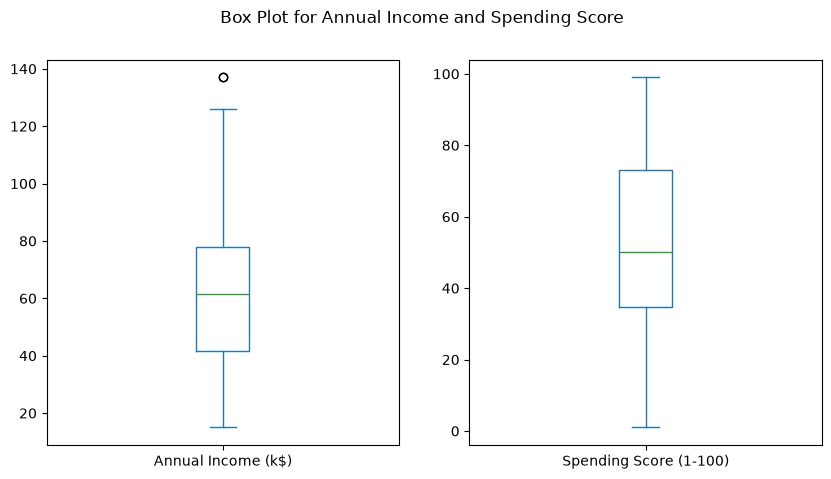

In [7]:
X.plot(kind='box', subplots=True, layout=(1, 2), figsize=(10, 5), title='Box Plot for Annual Income and Spending Score')

In [8]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)   
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:\n", lower_bound)
print("Upper Bound:\n", upper_bound)

Lower Bound:
 Annual Income (k$)       -13.250
Spending Score (1-100)   -22.625
dtype: float64
Upper Bound:
 Annual Income (k$)        132.750
Spending Score (1-100)    130.375
dtype: float64


In [9]:
outliers = ((X < lower_bound) | (X > upper_bound)).sum()
print("Number of outliers:\n", outliers)

Number of outliers:
 Annual Income (k$)        2
Spending Score (1-100)    0
dtype: int64


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
print(X_scaled[:5])  # Display the first 5 rows of the scaled data

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [12]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

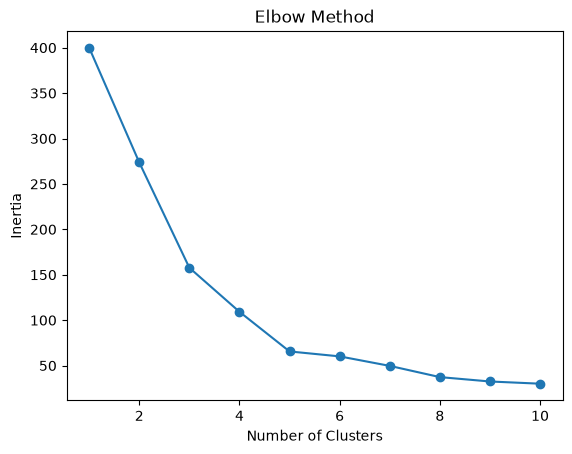

In [13]:
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

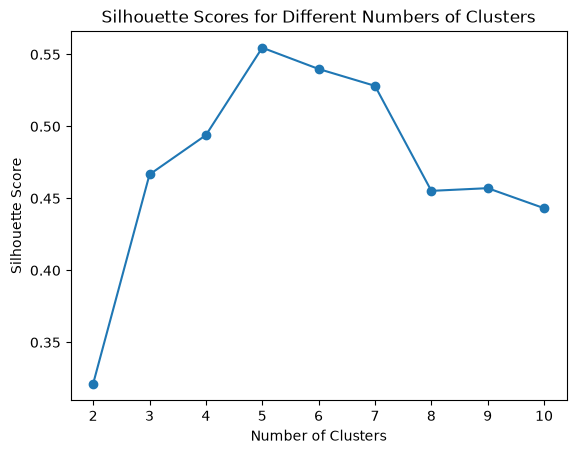

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [15]:
for k, s in zip(range(2, 11), silhouette_scores):
    print(f"Number of Clusters: {k}, Silhouette Score: {s:.4f}")

Number of Clusters: 2, Silhouette Score: 0.3213
Number of Clusters: 3, Silhouette Score: 0.4666
Number of Clusters: 4, Silhouette Score: 0.4939
Number of Clusters: 5, Silhouette Score: 0.5547
Number of Clusters: 6, Silhouette Score: 0.5399
Number of Clusters: 7, Silhouette Score: 0.5281
Number of Clusters: 8, Silhouette Score: 0.4552
Number of Clusters: 9, Silhouette Score: 0.4571
Number of Clusters: 10, Silhouette Score: 0.4432


In [16]:
best_k = range(2, 13)[silhouette_scores.index(max(silhouette_scores))]
print(f"The best number of clusters based on silhouette score is: {best_k}")

The best number of clusters based on silhouette score is: 5


In [17]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [18]:
print(df['Cluster'].value_counts().sort_index)

<bound method Series.sort_index of Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64>


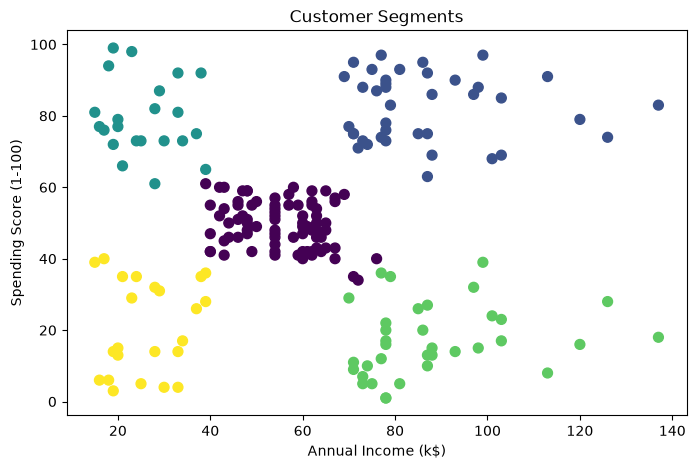

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df['Cluster'],
    cmap='viridis',
    s=50,
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [20]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

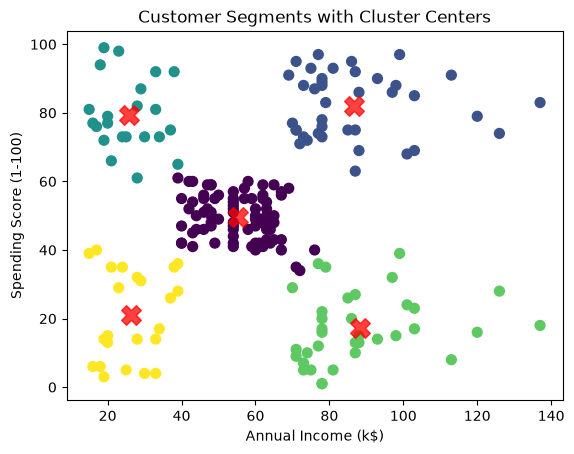

In [22]:
plt.Figure(figsize=(8, 5))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df['Cluster'],
    cmap='viridis',
    s=50,
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    alpha=0.75,
    marker='X',
    label='Centroids'
)
plt.title('Customer Segments with Cluster Centers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [26]:
centers_df = pd.DataFrame(
    centers, 
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

centers_df["clusters"] = range(5)
centers_df = centers_df.round(2)
# print(centers_df)
centers_df

,Annual Income (k$),Spending Score (1-100),clusters
0,55.30,49.52,0
1,86.54,82.13,1
2,25.73,79.36,2
3,88.20,17.11,3
4,26.30,20.91,4


In [27]:
def name_cluster(income, spending_score):
    if income < 40 and spending_score < 40:
        return 'Low Income, Low Spending'
    elif income < 40 and spending_score >= 60:
        return 'Low Income, High Spending'
    elif income >= 70 and spending_score < 60:
        return 'High Income, Low Spending'
    else:
        return 'High Income, High Spending'

centers_df['Name'] = centers_df.apply(
    lambda row: name_cluster(row['Annual Income (k$)'], row['Spending Score (1-100)']), axis=1
)

centers_df

,Annual Income (k$),Spending Score (1-100),clusters,Name
0,55.30,49.52,0,"High Income, High Spending"
1,86.54,82.13,1,"High Income, High Spending"
2,25.73,79.36,2,"Low Income, High Spending"
3,88.20,17.11,3,"High Income, Low Spending"
4,26.30,20.91,4,"Low Income, Low Spending"


In [28]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']